# Layer 2 diagnostic: Decision-level errors (antecedent decode)

This notebook analyzes the per-mention `decisions_*.jsonl` dumped by
`eval_signature_antecedent.py --save_decisions`.

Goals:
- Quantify how errors decompose into:
  - candidate_miss (gold antecedent absent from candidates)
  - epsilon_error (gold present but chose ε)
  - wrong_link (linked to wrong gold cluster)
- Identify worst topics
- Stratify errors by signature metadata (match_kind/type/relations/aliases, etc.)
- Surface “high-confidence” wrong links (likely to cause over-merges)


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# ----------------
# CONFIG (edit me)
# ----------------
DECISIONS_JSONL = Path("eval_outputs/analysis/scibert/16_hybrid_24_48_384/epoch3/decisions_validation.jsonl")  # <-- change
assert DECISIONS_JSONL.exists(), f"Missing: {DECISIONS_JSONL}"


In [3]:
# Load decisions
rows=[]
with DECISIONS_JSONL.open("r", encoding="utf-8") as f:
    for line in f:
        if not line.strip():
            continue
        rows.append(json.loads(line))
df = pd.DataFrame(rows)
print("rows:", len(df))
df.head()


rows: 4873


,split,topic_id,mention_idx,pid,start,end,gold_cluster,pred_cluster,has_gold_antecedent,gold_present,...,error_type,match_kind,match_kind_raw,used_extended_context,fallback_reason,sig_type,sig_n_aliases,sig_n_out,sig_n_in,sig_len_chars
0,validation,742,0,0,34,35,4,0,False,False,...,new_correct,rel,rel,False,,method,0,0,0,0
1,validation,742,1,1,20,22,11,0,False,False,...,new_wrong_link,rel,rel,False,,task,0,0,1,0
2,validation,742,2,2,32,33,4,0,True,True,...,correct_link,wd,wd,False,,task,0,2,1,0
3,validation,742,3,3,54,55,0,1,False,False,...,new_correct,wd,wd,False,,method,0,0,0,0
4,validation,742,4,4,11,13,0,1,True,True,...,correct_link,wd,wd,False,,method,0,1,1,0


In [4]:
# Basic sanity
# Focus on mentions that have a gold antecedent (otherwise 'new_correct/new_wrong_link' dominate)
df_has = df[df["has_gold_antecedent"] == True].copy()
print("mentions with gold antecedent:", len(df_has))

# Error type distribution
err_counts = df_has["error_type"].value_counts(dropna=False).to_frame("count")
err_counts["pct"] = err_counts["count"] / err_counts["count"].sum()
err_counts


mentions with gold antecedent: 3126


,count,pct
error_type,,
correct_link,2623,0.839091
epsilon_error,346,0.110685
wrong_link,156,0.049904
candidate_miss,1,0.000320


In [5]:
# Candidate miss rate should match Layer-1 recall
cand_miss = (df_has["error_type"] == "candidate_miss").mean()
eps_err = (df_has["error_type"] == "epsilon_error").mean()
wrong_link = (df_has["error_type"] == "wrong_link").mean()
correct_link = (df_has["error_type"] == "correct_link").mean()

print(f"candidate_miss rate: {cand_miss:.4f}")
print(f"epsilon_error  rate: {eps_err:.4f}")
print(f"wrong_link     rate: {wrong_link:.4f}")
print(f"correct_link   rate: {correct_link:.4f}")


candidate_miss rate: 0.0003
epsilon_error  rate: 0.1107
wrong_link     rate: 0.0499
correct_link   rate: 0.8391


In [6]:
# Per-topic error rates (mentions with gold antecedent only)
g = df_has.groupby("topic_id")
topic = pd.DataFrame({
    "n": g.size(),
    "cand_miss": g.apply(lambda x: (x["error_type"]=="candidate_miss").mean()),
    "eps_err": g.apply(lambda x: (x["error_type"]=="epsilon_error").mean()),
    "wrong_link": g.apply(lambda x: (x["error_type"]=="wrong_link").mean()),
    "correct_link": g.apply(lambda x: (x["error_type"]=="correct_link").mean()),
}).reset_index()

topic["err_total"] = topic["cand_miss"] + topic["eps_err"] + topic["wrong_link"]
topic = topic.sort_values("err_total", ascending=False)
topic.head(20)


C:\Users\jerry\AppData\Local\Temp\ipykernel_62224\589761674.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "cand_miss": g.apply(lambda x: (x["error_type"]=="candidate_miss").mean()),
C:\Users\jerry\AppData\Local\Temp\ipykernel_62224\589761674.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  "eps_err": g.apply(lambda x: (x["error_type"]=="epsilon_error").mean()),
C:\Users\jerry\AppData\Local\Temp\ipykernel_622

,topic_id,n,cand_miss,eps_err,wrong_link,correct_link,err_total
15,757,32,0.0,0.406250,0.125000,0.468750,0.531250
18,760,13,0.0,0.461538,0.000000,0.538462,0.461538
13,755,30,0.0,0.100000,0.333333,0.566667,0.433333
84,826,45,0.0,0.222222,0.200000,0.577778,0.422222
60,802,44,0.0,0.295455,0.113636,0.590909,0.409091
33,775,20,0.0,0.200000,0.200000,0.600000,0.400000
52,794,16,0.0,0.250000,0.125000,0.625000,0.375000
72,814,20,0.0,0.300000,0.050000,0.650000,0.350000
81,823,10,0.0,0.200000,0.100000,0.700000,0.300000
37,779,40,0.0,0.050000,0.250000,0.700000,0.300000


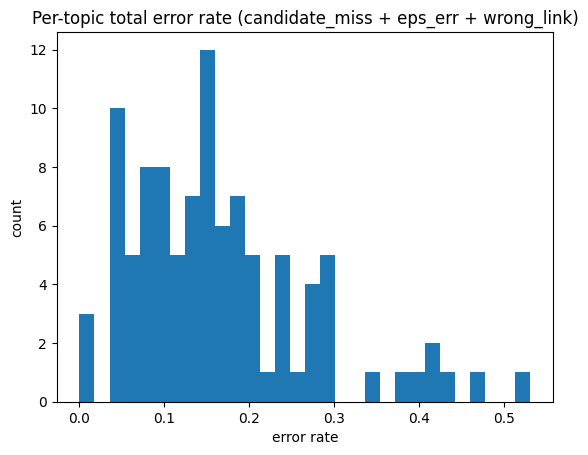

In [7]:
# Histograms
plt.figure()
plt.hist(topic["err_total"], bins=30)
plt.title("Per-topic total error rate (candidate_miss + eps_err + wrong_link)")
plt.xlabel("error rate")
plt.ylabel("count")
plt.show()


In [8]:
# Stratify by signature match_kind / type / richness
def strat(col):
    out = df_has.groupby(col).agg(
        n=("error_type","size"),
        cand_miss=("error_type", lambda s: (s=="candidate_miss").mean()),
        eps_err=("error_type", lambda s: (s=="epsilon_error").mean()),
        wrong_link=("error_type", lambda s: (s=="wrong_link").mean()),
        correct_link=("error_type", lambda s: (s=="correct_link").mean()),
    ).reset_index().sort_values("n", ascending=False)
    out["err_total"] = out["cand_miss"] + out["eps_err"] + out["wrong_link"]
    return out

for col in ["match_kind", "match_kind_raw", "used_extended_context", "fallback_reason", "sig_type"]:
    if col in df_has.columns:
        print("\n===", col, "===")
        display(strat(col).head(25))



=== match_kind ===


,match_kind,n,cand_miss,eps_err,wrong_link,correct_link,err_total
1,rel,2427,0.000000,0.111660,0.047796,0.840544,0.159456
0,none,402,0.002488,0.106965,0.064677,0.825871,0.174129
2,wd,297,0.000000,0.107744,0.047138,0.845118,0.154882



=== match_kind_raw ===


,match_kind_raw,n,cand_miss,eps_err,wrong_link,correct_link,err_total
1,rel,2427,0.000000,0.111660,0.047796,0.840544,0.159456
0,none,402,0.002488,0.106965,0.064677,0.825871,0.174129
2,wd,297,0.000000,0.107744,0.047138,0.845118,0.154882



=== used_extended_context ===


,used_extended_context,n,cand_miss,eps_err,wrong_link,correct_link,err_total
0,False,2713,0.000000,0.111316,0.047549,0.841135,0.158865
1,True,413,0.002421,0.106538,0.065375,0.825666,0.174334



=== fallback_reason ===


,fallback_reason,n,cand_miss,eps_err,wrong_link,correct_link,err_total
0,,2713,0.000000,0.111316,0.047549,0.841135,0.158865
1,no_match,402,0.002488,0.106965,0.064677,0.825871,0.174129
2,no_structured_info,11,0.000000,0.090909,0.090909,0.818182,0.181818



=== sig_type ===


,sig_type,n,cand_miss,eps_err,wrong_link,correct_link,err_total
16,task,1177,0.00000,0.089210,0.054376,0.856415,0.143585
7,method,960,0.00000,0.144792,0.039583,0.815625,0.184375
17,unknown,415,0.00241,0.108434,0.065060,0.824096,0.175904
12,other scientific term,410,0.00000,0.095122,0.053659,0.851220,0.148780
4,generic,67,0.00000,0.149254,0.014925,0.835821,0.164179
6,material,44,0.00000,0.136364,0.068182,0.795455,0.204545
9,metric,39,0.00000,0.025641,0.000000,0.974359,0.025641
10,motor,3,0.00000,0.000000,0.000000,1.000000,0.000000
2,conjunction = metric ensembles,1,0.00000,0.000000,0.000000,1.000000,0.000000
0,LAMB CPV,1,0.00000,0.000000,0.000000,1.000000,0.000000


In [9]:
# Richness buckets (aliases/relations)
for col in ["sig_n_aliases", "sig_n_out", "sig_n_in"]:
    if col not in df_has.columns:
        continue
    df_has[col] = pd.to_numeric(df_has[col], errors="coerce").fillna(0).astype(int)
    b = pd.cut(df_has[col], bins=[-1,0,1,2,100], labels=["0","1","2","3+"], include_lowest=True)
    out = df_has.groupby(b)["error_type"].agg(
        n="size",
        eps_err=lambda s: (s=="epsilon_error").mean(),
        wrong_link=lambda s: (s=="wrong_link").mean(),
        cand_miss=lambda s: (s=="candidate_miss").mean(),
    ).reset_index()
    out["err_total"] = out["eps_err"] + out["wrong_link"] + out["cand_miss"]
    print("\n===", col, "bucketed ===")
    display(out)



=== sig_n_aliases bucketed ===


C:\Users\jerry\AppData\Local\Temp\ipykernel_62224\2059827250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df_has.groupby(b)["error_type"].agg(


,sig_n_aliases,n,eps_err,wrong_link,cand_miss,err_total
0,0,3104,0.110180,0.049936,0.000322,0.160438
1,1,19,0.157895,0.052632,0.000000,0.210526
2,2,3,0.333333,0.000000,0.000000,0.333333
3,3+,0,NaN,NaN,NaN,NaN



=== sig_n_out bucketed ===


C:\Users\jerry\AppData\Local\Temp\ipykernel_62224\2059827250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df_has.groupby(b)["error_type"].agg(


,sig_n_out,n,eps_err,wrong_link,cand_miss,err_total
0,0,1934,0.100827,0.052740,0.000517,0.154085
1,1,890,0.122472,0.044944,0.000000,0.167416
2,2,247,0.137652,0.044534,0.000000,0.182186
3,3+,55,0.145455,0.054545,0.000000,0.200000



=== sig_n_in bucketed ===


C:\Users\jerry\AppData\Local\Temp\ipykernel_62224\2059827250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = df_has.groupby(b)["error_type"].agg(


,sig_n_in,n,eps_err,wrong_link,cand_miss,err_total
0,0,1869,0.108079,0.054040,0.000535,0.162654
1,1,964,0.113071,0.043568,0.000000,0.156639
2,2,228,0.140351,0.048246,0.000000,0.188596
3,3+,65,0.046154,0.030769,0.000000,0.076923


In [15]:
df_has

,split,topic_id,mention_idx,pid,start,end,gold_cluster,pred_cluster,has_gold_antecedent,gold_present,...,error_type,match_kind,match_kind_raw,used_extended_context,fallback_reason,sig_type,sig_n_aliases,sig_n_out,sig_n_in,sig_len_chars
2,validation,742,2,2,32,33,4,0,True,True,...,correct_link,wd,wd,False,,task,0,2,1,0
4,validation,742,4,4,11,13,0,1,True,True,...,correct_link,wd,wd,False,,method,0,1,1,0
5,validation,742,5,5,0,2,0,1,True,True,...,correct_link,rel,rel,False,,task,0,0,1,0
7,validation,742,7,7,11,13,5,2,True,True,...,correct_link,wd,wd,False,,method,0,1,0,0
8,validation,742,8,8,15,18,0,1,True,True,...,correct_link,rel,rel,False,,task,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4867,validation,841,49,47,63,66,10,12,True,True,...,correct_link,rel,rel,False,,task,0,0,2,0
4868,validation,841,50,48,20,21,6,13,True,True,...,epsilon_error,rel,rel,False,,task,0,0,0,0
4869,validation,841,51,49,3,4,6,13,True,True,...,correct_link,rel,rel,False,,task,0,1,0,0
4870,validation,841,52,50,29,33,6,13,True,True,...,correct_link,none,none,True,no_match,unknown,0,0,0,0


In [10]:
# High-confidence wrong links (likely merge culprits)
# Heuristic: large best-vs-second margin AND not a candidate_miss.
wl = df_has[df_has["error_type"]=="wrong_link"].copy()
wl["margin_best_vs_2nd"] = pd.to_numeric(wl["margin_best_vs_2nd"], errors="coerce")
wl["best_logit"] = pd.to_numeric(wl["best_logit"], errors="coerce")
wl["eps_logit"] = pd.to_numeric(wl["eps_logit"], errors="coerce")
wl["gap_vs_eps"] = wl["best_logit"] - wl["eps_logit"]

wl = wl.sort_values(["margin_best_vs_2nd","gap_vs_eps"], ascending=False)
wl.head(50)[[
    "topic_id","mention_idx","pid","start","end",
    "gold_cluster","chosen_gold_cluster",
    "pred_cluster","chosen_pred_cluster",
    "best_logit","eps_logit","gap_vs_eps","margin_best_vs_2nd",
    "match_kind","sig_type","sig_n_out","sig_n_in","sig_n_aliases"
]]


,topic_id,mention_idx,pid,start,end,gold_cluster,chosen_gold_cluster,pred_cluster,chosen_pred_cluster,best_logit,eps_logit,gap_vs_eps,margin_best_vs_2nd,match_kind,sig_type,sig_n_out,sig_n_in,sig_n_aliases
4543,835,37,36,11,12,19,8.0,8,8.0,5.193230,0.000603,5.192626,5.192626,rel,task,1,1,0
3156,805,44,44,44,47,4,0.0,10,10.0,5.117471,0.000603,5.116868,5.116868,rel,task,0,0,0
242,746,45,45,70,71,11,12.0,12,12.0,5.006145,0.000603,5.005541,5.005541,rel,other scientific term,0,0,0
3234,808,10,9,44,45,13,16.0,0,0.0,4.879575,0.000603,4.878972,4.878972,none,unknown,0,0,0
2942,801,26,26,29,30,17,7.0,0,0.0,4.805838,0.000603,4.805234,4.585325,none,unknown,0,0,0
2546,793,53,53,23,23,2,16.0,7,7.0,4.542593,0.000603,4.541990,4.541990,rel,method,1,1,0
2170,787,41,40,31,32,15,12.0,10,10.0,4.827004,0.000603,4.826401,4.128681,wd,task,1,0,0
3860,821,38,38,53,55,0,3.0,5,5.0,3.774884,0.000603,3.774281,3.774281,rel,method,0,0,0
1521,774,16,16,5,7,9,14.0,3,3.0,4.112046,0.000603,4.111443,3.751498,rel,other scientific term,0,0,0
2218,788,32,32,12,14,0,4.0,1,1.0,5.160102,0.000603,5.159499,3.718865,rel,method,2,2,0


In [11]:
# High-confidence epsilon errors (gold present but chose eps)
ee = df_has[df_has["error_type"]=="epsilon_error"].copy()
ee["p_eps"] = pd.to_numeric(ee["p_eps"], errors="coerce")
ee["p_gold"] = pd.to_numeric(ee["p_gold"], errors="coerce")
ee["best_gold_rank"] = pd.to_numeric(ee["best_gold_rank"], errors="coerce")

# sort by p_eps (very confident 'new'), then by low p_gold
ee = ee.sort_values(["p_eps","p_gold"], ascending=[False, True])

ee.head(50)[[
    "topic_id","mention_idx","pid","start","end",
    "gold_cluster","pred_cluster",
    "p_eps","p_gold","best_gold_rank",
    "match_kind","sig_type","sig_n_out","sig_n_in","sig_n_aliases","used_extended_context"
]]


,topic_id,mention_idx,pid,start,end,gold_cluster,pred_cluster,p_eps,p_gold,best_gold_rank,match_kind,sig_type,sig_n_out,sig_n_in,sig_n_aliases,used_extended_context
728,757,2,2,17,19,27,2,0.998099,0.001534,1.0,none,unknown,0,0,0,True
3522,814,5,5,36,38,0,4,0.997767,0.000636,1.0,rel,material,0,0,0,False
2392,791,6,5,39,40,6,2,0.997596,0.000902,2.0,none,unknown,0,0,0,True
501,752,9,8,23,25,1,5,0.995517,0.001935,1.0,rel,method,1,0,0,False
3709,818,2,2,35,36,0,2,0.995089,0.004626,1.0,none,unknown,0,0,0,True
3489,813,8,8,21,23,1,4,0.993931,0.002851,1.0,rel,task,1,1,0,False
2568,794,12,12,43,45,4,3,0.993722,0.001837,3.0,rel,task,3,2,0,False
2300,789,22,22,40,44,4,19,0.992662,0.002049,4.0,rel,task,0,0,0,False
815,758,24,24,37,39,10,5,0.992496,0.000592,12.0,rel,method,1,2,0,False
2982,802,17,17,21,23,0,8,0.992088,0.000962,1.0,rel,method,0,0,0,False


{"topic_id": 986, "doc_id": 0, "para_idx": 0, "sent_idx": 1, "gold_span": [25, 25], "gold_text": "DBSCAN", "cluster_id": 18, "match_kind": "none", "match_kind_raw": "none", "matched_wd_span": false, "matched_rel_span": false, "used_extended_context": true, "fallback_reason": "no_match", "sig_canonical": "DBSCAN", "sig_type": "unknown", "sig_n_aliases": 0, "sig_n_out": 0, "sig_n_in": 0, "signature": "<M> <m>DBSCAN</m> <CANON> DBSCAN <TYPE> unknown <CTX> In this paper, we present lesion detection schemes in dermoscopy images on mobile platforms. The systems are based on density based clustering (<m>DBSCAN</m>) and fuzzy c-means (FCM) clustering and developed for Windows Phone and Android environments. We tested the systems on dermoscopy images and ROIs are successfully extracted."}
{"topic_id": 986, "doc_id": 1, "para_idx": 1, "sent_idx": 1, "gold_span": [42, 43], "gold_text": "DB-SCAN algorithm", "cluster_id": 18, "match_kind": "rel", "match_kind_raw": "rel", "matched_wd_span": false, "matched_rel_span": true, "used_extended_context": false, "fallback_reason": "", "sig_canonical": "DB-SCAN algorithm", "sig_type": "method", "sig_n_aliases": 0, "sig_n_out": 0, "sig_n_in": 0, "signature": "<M> <m>DB-SCAN algorithm</m> <CANON> DB-SCAN algorithm <TYPE> method <CTX> The method proposed in this paper clustered taxi Origin-Destination data points of the functional region with the improved <m>DB-SCAN algorithm</m> and yielded the areas of interest with the statistical method named Chi-square distribution."}

{"topic_id": 986, "para_idx": 0, "doc_id": 0, "flatten_offset": 0, "n_tokens": 56, "text": "In this paper, we present lesion detection schemes in dermoscopy images on mobile platforms. The systems are based on density based clustering (DBSCAN) and fuzzy c-means (FCM) clustering and developed for Windows Phone and Android environments. We tested the systems on dermoscopy images and ROIs are successfully extracted.", "tanl_output": "In this paper, we present [ lesion detection schemes | method ] in dermoscopy images on [ mobile platforms | material | used for = lesion detection schemes ] . The [ systems | generic ] are based on [ density based clustering (DBSCAN) and fuzzy c-means (FCM) clustering | method | used for = systems ] and developed for [ Windows Phone and Android environments | task ] . We tested the [ systems | generic ] on [ dermoscopy images | material | evaluate for = systems ] and [ ROIs | material | evaluate for = systems ] are successfully extracted.", "sentences": [[0, 16], [16, 43], [43, 56]]}
{"topic_id": 986, "para_idx": 1, "doc_id": 1, "flatten_offset": 56, "n_tokens": 85, "text": "The problem occurs due to dispatching taxis is not in line with the taxi demand in different functional regions during different time periods. The method proposed in this paper clustered taxi Origin-Destination data points of the functional region with the improved DB-SCAN algorithm and yielded the areas of interest with the statistical method named Chi-square distribution. The accuracy and credibility of the method was evaluated through two indicators called coverage and hit ratio and a comparison analysis on situations of different regions.", "tanl_output": "The problem occurs due to dispatching taxis is not in line with the taxi demand in different functional regions during different time periods. The [ method | generic ] proposed in this paper clustered taxi Origin-Destination data points of the functional region with the improved [ DB-SCAN algorithm | method ] and yielded the areas of interest with the [ statistical method | method ] named [ Chi-square distribution | method | hyponym of = statistical method ] . The accuracy and credibility of the [ method | generic ] was evaluated through two [ indicators | generic | evaluate for = method ] called [ coverage | metric | evaluate for = method ] and a [ comparison analysis | method ] on situations of different regions.", "sentences": [[0, 24], [24, 58], [58, 85]]}
